# Financial Sentiment Classifier — LoRA Fine-tuning

End-to-end runner. Goes through: setup → data → baselines → LoRA training → eval.

**Before you start**:
1. `Runtime` → `Change runtime type` → **T4 GPU** (free tier).
2. Run the first cell to confirm the GPU is attached.
3. Then run cells top-to-bottom.

Total wall-clock time on T4: roughly 45–60 minutes.

## 1. Verify GPU

If you see `Tesla T4` (or another NVIDIA GPU), you're good.

In [1]:
!nvidia-smi

Sun May 24 21:05:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Pull latest code

If you're running this in Colab for the first time, the `cd` will fail — uncomment the clone line. On re-runs, just `git pull`.

In [2]:
# First run only:
!git clone https://github.com/David0hy/llm-financial-sentiment-lora.git
%cd /content/llm-financial-sentiment-lora
!git pull

Cloning into 'llm-financial-sentiment-lora'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 1), reused 14 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 13.08 KiB | 13.08 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/llm-financial-sentiment-lora
Already up to date.


## 3. Install dependencies

~3 minutes.

In [3]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.7 MB/s eta 0:00:00


## 4. Build the dataset

Pulls `zeroshot/twitter-financial-news-sentiment` from HuggingFace and writes 600 balanced examples (200 each of bearish / bullish / neutral) to `data/samples.jsonl`.

**Expected time**: 30 seconds (the dataset is only ~1MB).

In [4]:
!python data/build_dataset.py --output data/samples.jsonl --n 600

Loading zeroshot/twitter-financial-news-sentiment from HuggingFace...
README.md: 1.39kB [00:00, 4.90MB/s]
sent_train.csv: 859kB [00:00, 104MB/s]
sent_valid.csv: 217kB [00:00, 103MB/s]
Generating train split: 100% 9543/9543 [00:00<00:00, 275742.59 examples/s]
Generating validation split: 100% 2388/2388 [00:00<00:00, 298601.73 examples/s]
  Loaded 11931 total examples
  Class counts in source: bearish=1789, bullish=2398, neutral=7744

Wrote 598 samples to data/samples.jsonl
Label distribution: {'bullish': 200, 'neutral': 198, 'bearish': 200}
Split distribution: {'train': 418, 'val': 90, 'test': 90}


In [5]:
# Quick sanity check
import json
from collections import Counter

with open("data/samples.jsonl") as f:
    samples = [json.loads(line) for line in f]

print(f"Total samples: {len(samples)}")
print("Label distribution:", Counter(s["label"] for s in samples))
print("Split distribution:", Counter(s["split"] for s in samples))
print("\nExample bearish tweet:")
for s in samples:
    if s["label"] == "bearish":
        print(f"  {s['text']}")
        break
print("\nExample bullish tweet:")
for s in samples:
    if s["label"] == "bullish":
        print(f"  {s['text']}")
        break

Total samples: 598
Label distribution: Counter({'bullish': 200, 'bearish': 200, 'neutral': 198})
Split distribution: Counter({'train': 418, 'val': 90, 'test': 90})

Example bearish tweet:
  Tyson Foods EPS misses by $0.01, misses on revenue

Example bullish tweet:
  $W - Wayfair +4% after BofA bump


## 5. Baseline: Qwen2.5-1.5B zero-shot

Apples-to-apples — same base model we'll fine-tune, evaluated with prompting alone.

**Expected time**: ~10 minutes (downloads the 3GB base model first time).

In [6]:
!python src/prompting_baseline.py --model qwen --data data/samples.jsonl --out results/qwen_zero_shot.json

Predicting on 90 test samples...
config.json: 100% 660/660 [00:00<00:00, 2.73MB/s]
tokenizer_config.json: 7.30kB [00:00, 20.4MB/s]
vocab.json: 2.78MB [00:00, 93.6MB/s]
merges.txt: 1.67MB [00:00, 73.3MB/s]
tokenizer.json: 7.03MB [00:00, 151MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100% 3.09G/3.09G [00:30<00:00, 100MB/s]
Loading weights: 100% 338/338 [00:08<00:00, 37.95it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 242/242 [00:00<00:00, 1.29MB/s]
qwen zero-shot:   0% 0/90 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
qwen zero-shot: 100% 90/90 [00:12<00:00,  7.23it/s]
Saved predictions to results/qwen_zero_shot.json


## 6. (Optional) Baseline: GPT-4o-mini

Skip this if you don't want to spend ~$0.02 in API credits. The Qwen zero-shot vs Qwen LoRA comparison is the more important one anyway.

In [ ]:
# import os
# os.environ["OPENAI_API_KEY"] = "sk-REPLACE-ME"
# !python src/prompting_baseline.py --model gpt-4o-mini --data data/samples.jsonl --out results/gpt4o_mini_zero_shot.json
print("Skipped — uncomment the lines above and add your API key to run.")

## 7. Train LoRA

**This is the main event.** ~15–20 minutes on T4.

Watch the early output for:
- `trainable params: X || all params: Y || trainable%: ~0.6%` — confirms LoRA is wired right.
- Loss decreasing across epochs.

**If it OOMs**: reduce `--batch` from 4 to 2, or add `--quant` for QLoRA.

In [9]:
!python src/train_lora.py \
  --base Qwen/Qwen2.5-1.5B-Instruct \
  --data data/samples.jsonl \
  --out checkpoints/lora_r16 \
  --rank 16 \
  --epochs 3 \
  --batch 4

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 338/338 [00:02<00:00, 121.19it/s, Materializing param=model.norm.weight]
trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815
Map: 100% 418/418 [00:00<00:00, 4556.43 examples/s]
Map: 100% 90/90 [00:00<00:00, 7220.49 examples/s]
Map: 100% 418/418 [00:00<00:00, 4063.10 examples/s]
Map: 100% 90/90 [00:00<00:00, 3504.11 examples/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
{'loss': '3.665', 'grad_norm': '2.292', 'learning_rate': '0.00018', 'epoch': '0.09524'}
{'loss': '1.856', 'grad_norm': '2.012', 'learning_rate': '0.0001996', 'epoch': '0.1905'}
{'loss': '0.9687', 'grad_norm': '0.9109', 'learning_rate': '0.0001981', 'epoch': '0.2857'}
{'loss': '0.8391', 'grad_norm': '0.6903', 'learning_rate': '0.0001956', 'epoch': '0.381'}
{'los

## 8. Inference with the trained adapter

~3 minutes.

In [10]:
!python src/infer_lora.py \
  --base Qwen/Qwen2.5-1.5B-Instruct \
  --adapter checkpoints/lora_r16 \
  --data data/samples.jsonl \
  --out results/lora_r16.json

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 338/338 [00:02<00:00, 122.07it/s, Materializing param=model.norm.weight]
lora inference:   0% 0/90 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
lora inference: 100% 90/90 [00:16<00:00,  5.52it/s]
Saved to results/lora_r16.json


## 9. Evaluate everything

In [11]:
!python src/eval.py --all


Approach                                     N     Acc   Macro F1
----------------------------------------------------------------------
lora_r16                                    90   0.856      0.861
qwen_zero_shot                              90   0.867      0.872

Per-class F1:
  lora_r16: bearish=0.86  bullish=0.91  neutral=0.81
  qwen_zero_shot: bearish=0.86  bullish=0.93  neutral=0.82


## 10. Visualize confusion matrices

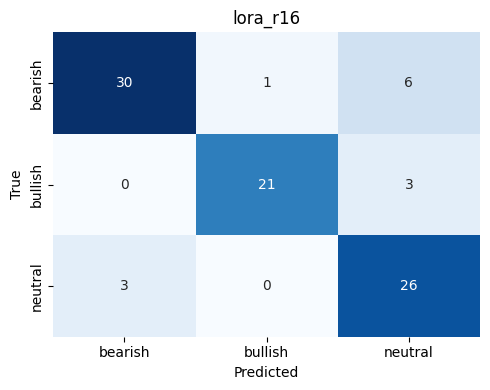

Saved figures/lora_r16.png


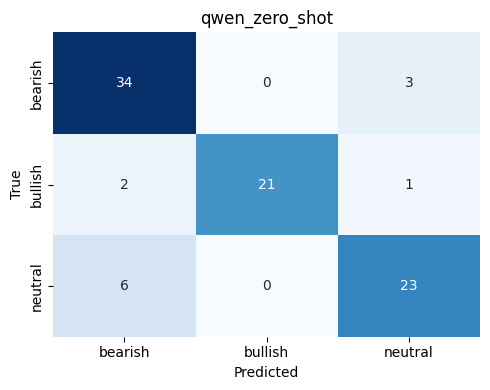

Saved figures/qwen_zero_shot.png


In [12]:
import json, glob
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

LABELS = ["bearish", "bullish", "neutral"]
Path("figures").mkdir(exist_ok=True)

def normalize(p):
    p = p.strip().lower()
    for l in LABELS:
        if l in p:
            return l
    return "unknown"

for path in sorted(glob.glob("results/*.json")):
    with open(path) as f:
        preds = json.load(f)
    y_true = [p["label"] for p in preds]
    y_pred = [normalize(p["pred"]) for p in preds]
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    name = Path(path).stem
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    out = f"figures/{name}.png"
    plt.savefig(out, dpi=120)
    plt.show()
    print(f"Saved {out}")

## Done

You should now have:
- `results/qwen_zero_shot.json` — baseline predictions
- `results/lora_r16.json` — LoRA predictions
- `checkpoints/lora_r16/` — trained adapter weights
- `figures/*.png` — confusion matrices

See the README for the headline result: **LoRA did not beat zero-shot on
this task (85.6% vs 86.7%).** This is a real finding, not a bug — when the
base model already saturates the task, parameter-efficient fine-tuning
provides diminishing returns. The README walks through three explanatory
factors and the engineering takeaway.

### Reproducing variations

To run the ablations referenced in the README:

```bash
# Stop at epoch 2 (where eval loss was lowest)
!python src/train_lora.py --epochs 2 --out checkpoints/lora_r16_e2

# Lower-rank adapter (less capacity, less overfit risk)
!python src/train_lora.py --rank 8 --out checkpoints/lora_r8
```

Then re-run inference + eval on the new adapter and compare.